# House price regression: analysis

The original notebook (`HousePricePrediction (1).ipynb`) trained a Linear Regression (R² = 0.676) and a tuned Random Forest (R² = 0.822) on the California housing data, evaluating with R² only and without fixing a random seed.

This add-on keeps the same preprocessing ideas (log transform of skewed counts, one-hot `ocean_proximity`, the two engineered ratios) but wraps them in a leak-free scikit-learn pipeline, fixes the seed, and evaluates more thoroughly:

1. several models compared on RMSE, MAE and R²,
2. cross-validation,
3. residual and error analysis,
4. feature importance.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # silences a joblib core-count warning on Windows
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
SEED = 42
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("housing.csv")
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 1. A quick look at the data

Missing values: {'total_bedrooms': 207}
Rows at the price cap (500,001): 965 (4.7%)


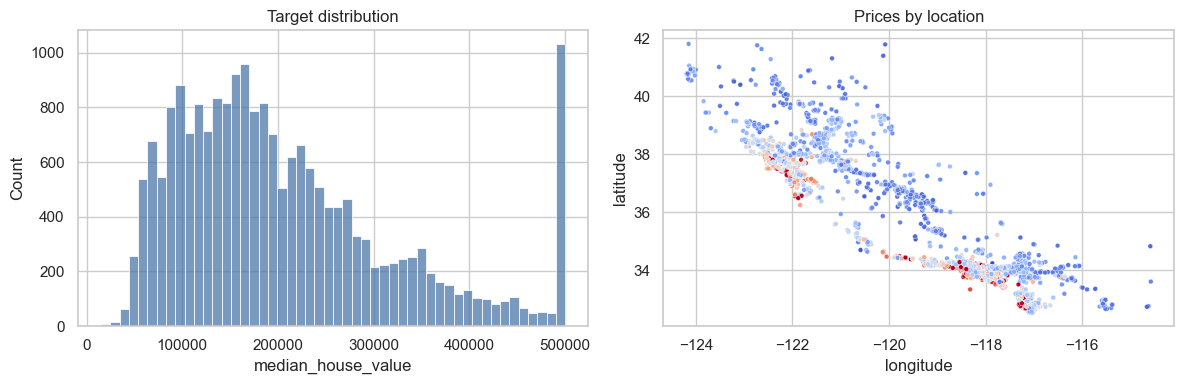

In [2]:
print("Missing values:", df.isna().sum()[df.isna().sum() > 0].to_dict())
cap = (df["median_house_value"] == df["median_house_value"].max()).sum()
print(f"Rows at the price cap ({df['median_house_value'].max():,.0f}): {cap} ({cap/len(df):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["median_house_value"], bins=50, ax=axes[0], color="#4C78A8"); axes[0].set_title("Target distribution")
sns.scatterplot(data=df.sample(4000, random_state=SEED), x="longitude", y="latitude",
                hue="median_house_value", palette="coolwarm", s=12, ax=axes[1], legend=False)
axes[1].set_title("Prices by location"); plt.tight_layout(); plt.show()

The target is **capped** at about $500k, which limits how well any model can do on the most expensive districts. Next the features and models.

In [3]:
def add_features(d):
    d = d.copy()
    d["bedroom_ratio"] = d["total_bedrooms"] / d["total_rooms"]
    d["households_rooms"] = d["total_rooms"] / d["households"]
    return d

log_cols = ["total_rooms", "total_bedrooms", "population", "households"]
num_cols = ["longitude", "latitude", "housing_median_age", "median_income", "bedroom_ratio", "households_rooms"]
cat_cols = ["ocean_proximity"]

def make_prep(log_scale=True, scale=True):
    num_steps = [SimpleImputer(strategy="median")] + ([StandardScaler()] if scale else [])
    log_steps = [SimpleImputer(strategy="median"), FunctionTransformer(np.log1p, feature_names_out="one-to-one")] + ([StandardScaler()] if scale else [])
    return ColumnTransformer([
        ("num", make_pipeline(*num_steps), num_cols),
        ("log", make_pipeline(*log_steps), log_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])

X = add_features(df.drop(columns="median_house_value"))
y = df["median_house_value"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (16512, 11) | test: (4128, 11)


## 2. Model comparison

In [4]:
models = {
    "Linear Regression": make_pipeline(make_prep(), LinearRegression()),
    "Ridge": make_pipeline(make_prep(), Ridge(alpha=1.0)),
    "Random Forest": make_pipeline(make_prep(scale=False), RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED)),
    "Gradient Boosting": make_pipeline(make_prep(scale=False), HistGradientBoostingRegressor(max_iter=300, learning_rate=0.1, random_state=SEED)),
}
rows, fitted = [], {}
for name, m in models.items():
    m.fit(X_train, y_train); fitted[name] = m
    p = m.predict(X_test)
    rows.append({"model": name, "RMSE": np.sqrt(mean_squared_error(y_test, p)),
                 "MAE": mean_absolute_error(y_test, p), "R²": r2_score(y_test, p)})
results = pd.DataFrame(rows).set_index("model")
results.round({"RMSE": 0, "MAE": 0, "R²": 4})

,RMSE,MAE,R²
model,,,
Linear Regression,67254.0,48370.0,0.6548
Ridge,67262.0,48374.0,0.6548
Random Forest,49135.0,31760.0,0.8158
Gradient Boosting,46865.0,31440.0,0.8324


## 3. Cross-validated R²

In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for name, m in models.items():
    s = cross_val_score(m, X, y, cv=cv, scoring="r2", n_jobs=1)
    cv_rows.append({"model": name, "CV R²": s.mean(), "± std": s.std()})
cv_results = pd.DataFrame(cv_rows).set_index("model").round(4)
cv_results

,CV R²,± std
model,,
Linear Regression,0.6702,0.0153
Ridge,0.6702,0.0154
Random Forest,0.8215,0.0085
Gradient Boosting,0.8410,0.0056


## 4. Error analysis of the best model

Best model: Gradient Boosting


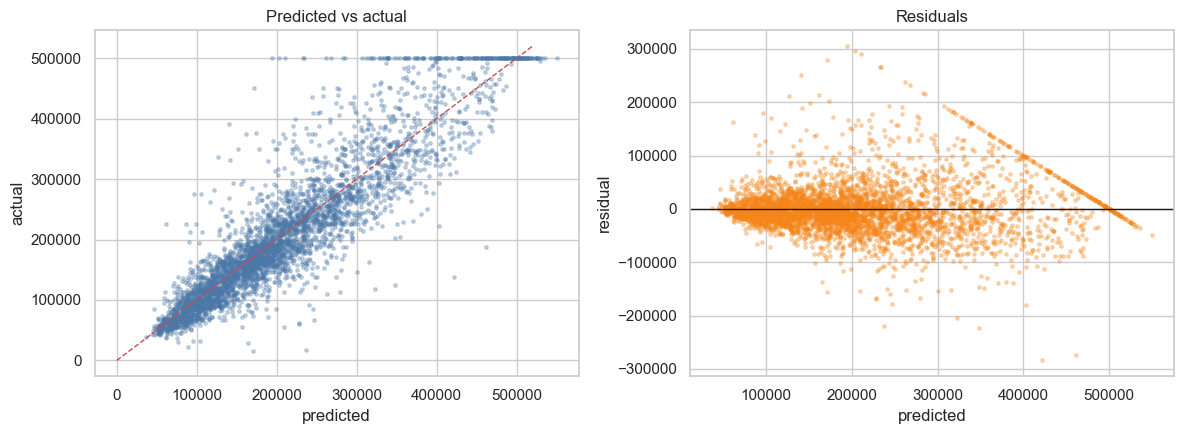

,mean absolute error ($),districts
zone,,
INLAND,23515.0,1324
<1H OCEAN,33339.0,1795
NEAR OCEAN,38336.0,572
NEAR BAY,38465.0,436
ISLAND,108012.0,1


In [6]:
best_name = results["R²"].idxmax()
best = fitted[best_name]
pred = best.predict(X_test)
resid = y_test - pred
print("Best model:", best_name)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred, y_test, s=6, alpha=0.3, color="#4C78A8")
lim = [0, 520000]; axes[0].plot(lim, lim, "r--", lw=1)
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual"); axes[0].set_title("Predicted vs actual")
axes[1].scatter(pred, resid, s=6, alpha=0.3, color="#F58518"); axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual"); axes[1].set_title("Residuals")
plt.tight_layout(); plt.show()

by_zone = (pd.DataFrame({"zone": X_test["ocean_proximity"], "abs_err": resid.abs()})
           .groupby("zone")["abs_err"].agg(["mean", "count"]).round(0).sort_values("mean"))
by_zone.rename(columns={"mean": "mean absolute error ($)", "count": "districts"})

## 5. Feature importance (Random Forest)

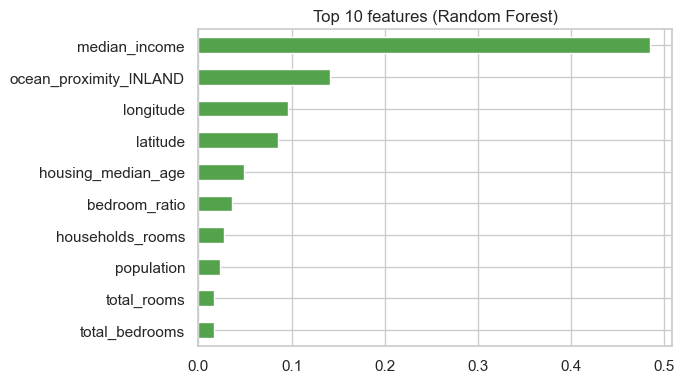

In [7]:
rf = fitted["Random Forest"]
names = rf[0].get_feature_names_out()
imp = pd.Series(rf[-1].feature_importances_, index=[n.split("__")[-1] for n in names]).sort_values().tail(10)
imp.plot.barh(figsize=(7, 4), color="#54A24B")
plt.title("Top 10 features (Random Forest)"); plt.tight_layout(); plt.show()

## Conclusions

- **Gradient boosting is the best model**: test R² 0.832 (RMSE ≈ $46.9k, MAE ≈ $31.4k) and cross-validated R² 0.841 ± 0.006. Random Forest is close (CV 0.822), matching the tuned Random Forest of the original notebook (0.822).
- Linear models plateau at R² ≈ 0.67, in line with the original Linear Regression (0.676). The large gap to tree models means the relationship, especially through location, is strongly non-linear.
- Ridge gives no gain over plain Linear Regression, so over-fitting is not the limitation.
- Errors are smallest inland (MAE ≈ $23.5k) and largest near the coast and bay (≈ $38k), where prices are higher and more variable. The single `ISLAND` district in the test set is not statistically meaningful.

**Caveats:** the target is capped at $500,001 (4.7% of districts), which compresses the highest prices and caps achievable accuracy there; the data is from the 1990 census; rows are districts, not individual houses. The original notebook used no random seed, so its numbers vary slightly between runs.